# Pytorch

PyTorch is a package for computing gradients automatically, and more broadly for deep learning.

If you don't already have the PyTorch installed you will need to follow the
[PyTorch Get Started](https://pytorch.org/get-started/locally/)
instructions for your platform. For example with Anaconda, if your platform doesn't have a GPU use:

`conda install pytorch torchvision torchaudio cpuonly -c pytorch`

If you have a GPU, use

`conda install pytorch torchvision torchaudio cudatoolkit=10.2 -c pytorch`
Replacing the version number of CUDA as appropriate - see
[PyTorch Get Started](https://pytorch.org/get-started/locally/)

There is a short section on using a GPU at the end of this notebook.

[documentation](https://pytorch.org/docs/stable/index.html)
and
[tutorials](https://pytorch.org/tutorials/)
are available on the
[PyTorch website](https://pytorch.org/).

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

%matplotlib ipympl
#%matplotlib inline
#%matplotlib notebook

## Tensors
In torch, array-like data is referred to as a tensor and stored as an instance of the class `torch.Tensor`. Tensors are similar to NumPy ndarrays. Many of the function names are the same.

In the following example, we create a 1-D tensor with four floating point values and a 2-D tensor with integer values.

In [2]:
x = torch.tensor([5.0, 3, 6.6, 1])    # a 1-D tensor (vector)
print(x)

y = torch.tensor([[1, 2],[4, 5]])    # a 2-D tensor (matrix)
print(y)

print(y*y)    # element-wise (Hadamard) product (unlike Matlab, where this would be matrix multiplication)

print(torch.matmul(y,y))

tensor([5.0000, 3.0000, 6.6000, 1.0000])
tensor([[1, 2],
        [4, 5]])
tensor([[ 1,  4],
        [16, 25]])
tensor([[ 9, 12],
        [24, 33]])


However, torch goes beyond NumPy in making it easy to compute gradients of outputs with respect to inputs. This makes torch well suited to optimisation. To turn on this functionality, let torch know on creation of a tensor.

In this example, we create a tensor from a scalar value $x$, and compute $z=x^2$. From calculus, we know that $\frac{dz}{dx}=2x$.

The arithmetic operation `z=x**2` builds a computation graph on the fly and `z.backward` implements backpropagation from the output variable `z`. As a result, the `grad` attribute contains the gradient - in this example, a tensor with a single scalar.

Note that Tensors requiring gradient must be floating point (or complex) data types.

In [3]:
x = torch.tensor(3.0, requires_grad=True)
z = x**2
z.backward()
print(x.grad)

tensor(6.)


For a function of more than one variable, we obtain the partial derivatives of the output with respect to each one.

$z=3xy+y^2$ for which the partial derivatives are $\frac{\partial z}{\partial x}=3y$ and $\frac{\partial z}{\partial y}=3x+2y$

In [4]:
x = torch.tensor(3.0, requires_grad=True)
y = torch.tensor(5.0, requires_grad=True)

z = 3*x*y + y**2
z.backward()

print(x.grad)
print(y.grad)

tensor(15.)
tensor(19.)


Here we compute the gradients for a more complicated function.

In [5]:
x = torch.tensor(3.0, requires_grad=True)
y = torch.tensor(5.0, requires_grad=True)

p = torch.sqrt(3*x.sin())
q = 4*(y**3).cos()
z=p+q

z.backward()

print(x.grad)
print(y.grad)


tensor(-2.2823)
tensor(184.8121)


In building the computation graph, torch adds an attribute grad_fn to each node. This contains the function required to backpropagate the elementary function creating that node. In the case of `z`, this is the final addition combining p and q.

In [6]:
print(z)

tensor(3.8015, grad_fn=<AddBackward0>)


So far we have been working with tensors consisting of a single scalar. torch is able to compute gradients for n-dimensional tensors, containing many scalar values. These tensors sit at the nodes of the computation graph and backpropagation is handled very efficiently.  Note that the function output has to be scalar.

In [7]:
x = torch.tensor([1., 3., 2., 5.], requires_grad=True)
z = x**2
z = z.sum()    # sums the outputs, producing a scalar result
print(z)
z.backward()
print(x.grad)

tensor(39., grad_fn=<SumBackward0>)
tensor([ 2.,  6.,  4., 10.])


In [8]:
x = torch.tensor([[1., 3.], [2., 5.]], requires_grad=True)
z = x**2
z = z.sum()    # sums the outputs, producing a scalar result
print(z)
z.backward()
print(x.grad)

tensor(39., grad_fn=<SumBackward0>)
tensor([[ 2.,  6.],
        [ 4., 10.]])


It is sometimes convenient to create a tensor from a NumPy array.

In [9]:
x = np.array([[1.,2.,3.],[4.,5.,6.]])
print(x)
y = torch.tensor(x, requires_grad=True)
print(y)

[[1. 2. 3.]
 [4. 5. 6.]]
tensor([[1., 2., 3.],
        [4., 5., 6.]], dtype=torch.float64, requires_grad=True)


## Optimisation
Now we'll use PyTorch for optimisation. Consider the function $z = (x-5)^2+(y-7)^2 + 20$. This has a minimum at $x=5, y=7$. We'll use Gradient Descent and start out from $x=0, y=0$.

The two input variables $x$ and $y$ will be wrapped into a single Tensor `p` for convenience.

In [10]:
# create an input tensor with initial values
p = torch.tensor([0., 0.], requires_grad=True)

iterations = 50
# create and ndarray to record the trajectory 
history = np.zeros((iterations,3))
stepsize = 0.1
for i in range(iterations): 
    
    # forward step (i.e. computing the function for current input)
    z = sum((p - torch.tensor([5,7]))**2) + 20
    
    # backpropagation of gradients
    z.backward()
    
    # disable gradient computations to perform update
    with torch.no_grad():
        p = p - stepsize*p.grad
             
        z = sum((p - torch.tensor([5,7]))**2) + 20  # new value for display and history
        print(f"iteration {i+1}: x ={p[0].numpy(): .2f}, y ={p[1].numpy(): .2f}, z ={z: .2f}")
        history[i,0:2] = p.data
        history[i,2] = z
       
    # new p requires_grad=False so turn on
    p = p.requires_grad_(True)
    
# Alternative update that works in-place on p
# Disable gradient compututations and update p in-place
#    with torch.no_grad():
#        p += -0.1*p.grad
#   zero out p.grad (in-place) prior to next iteration
#   p.grad.zero_()

iteration 1: x = 1.00, y = 1.40, z = 67.36
iteration 2: x = 1.80, y = 2.52, z = 50.31
iteration 3: x = 2.44, y = 3.42, z = 39.40
iteration 4: x = 2.95, y = 4.13, z = 32.42
iteration 5: x = 3.36, y = 4.71, z = 27.95
iteration 6: x = 3.69, y = 5.16, z = 25.09
iteration 7: x = 3.95, y = 5.53, z = 23.25
iteration 8: x = 4.16, y = 5.83, z = 22.08
iteration 9: x = 4.33, y = 6.06, z = 21.33
iteration 10: x = 4.46, y = 6.25, z = 20.85
iteration 11: x = 4.57, y = 6.40, z = 20.55
iteration 12: x = 4.66, y = 6.52, z = 20.35
iteration 13: x = 4.73, y = 6.62, z = 20.22
iteration 14: x = 4.78, y = 6.69, z = 20.14
iteration 15: x = 4.82, y = 6.75, z = 20.09
iteration 16: x = 4.86, y = 6.80, z = 20.06
iteration 17: x = 4.89, y = 6.84, z = 20.04
iteration 18: x = 4.91, y = 6.87, z = 20.02
iteration 19: x = 4.93, y = 6.90, z = 20.02
iteration 20: x = 4.94, y = 6.92, z = 20.01
iteration 21: x = 4.95, y = 6.94, z = 20.01
iteration 22: x = 4.96, y = 6.95, z = 20.00
iteration 23: x = 4.97, y = 6.96, z = 20.

Show the surface and $(x,y)$ trajectory of the gradient descent

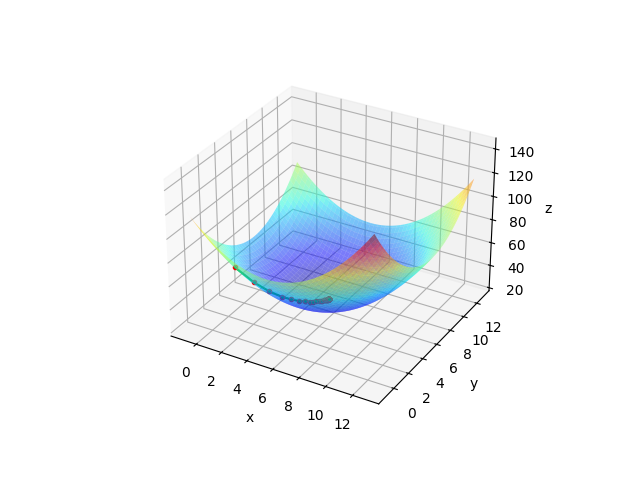

In [14]:
# Make data.
X = np.arange(-1,13, 0.1)
Y = np.arange(-1,13, 0.1)
X, Y = np.meshgrid(X, Y)

Z = ((X-5)**2 + (Y-7)**2) + 20

# Plot the surface.
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(X,Y,Z, cmap='jet', antialiased=True, alpha=0.5)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.plot(history[:,0], history[:,1], history[:,2], color='green', marker='.', markeredgecolor='red')

plt.show()

## Exercise

Modify the code above to minimise and visualise the Rosenbrock function $f(x,y)=(a-x)^2+b(y-x^2)^2$

Try setting $a=1$ and $b=100$. Start from $x=-3, y=-4$

In [49]:
# create an input tensor with initial values
xy = np.array([-3.,-4.])
a = 1
b = 100
p = torch.tensor(xy, requires_grad=True)

iterations = 100000
# create and ndarray to record the trajectory 
history = np.zeros((iterations,3))
stepsize = 0.0002
for i in range(iterations): 
    
    # forward step (i.e. computing the function for current input)
    #z = sum((p - torch.tensor([5,7]))**2) + 20
    z = (a-p[0])**2 + b*((p[1] - p[0]**2)**2)
    
    # backpropagation of gradients
    z.backward()
    
    # disable gradient computations to perform update
    with torch.no_grad():
        p = p - stepsize*p.grad
             
        #z = sum((p - torch.tensor([5,7]))**2) + 20  # new value for display and history
        z = (a-p[0])**2 + b*((p[1] - p[0]**2)**2)

        if i%(iterations/10) == 0:
            print(f"iteration {i+1}: x ={p[0].numpy(): .2f}, y ={p[1].numpy(): .2f}, z ={z: .2f}")
        history[i,0:2] = p.data
        history[i,2] = z
       
    # new p requires_grad=False so turn on
    p = p.requires_grad_(True)
    

iteration 1: x = 0.12, y =-3.48, z = 1222.12
iteration 10001: x = 0.82, y = 0.67, z = 0.03
iteration 20001: x = 0.93, y = 0.87, z = 0.00
iteration 30001: x = 0.97, y = 0.94, z = 0.00
iteration 40001: x = 0.99, y = 0.97, z = 0.00
iteration 50001: x = 0.99, y = 0.99, z = 0.00
iteration 60001: x = 1.00, y = 0.99, z = 0.00
iteration 70001: x = 1.00, y = 1.00, z = 0.00
iteration 80001: x = 1.00, y = 1.00, z = 0.00
iteration 90001: x = 1.00, y = 1.00, z = 0.00


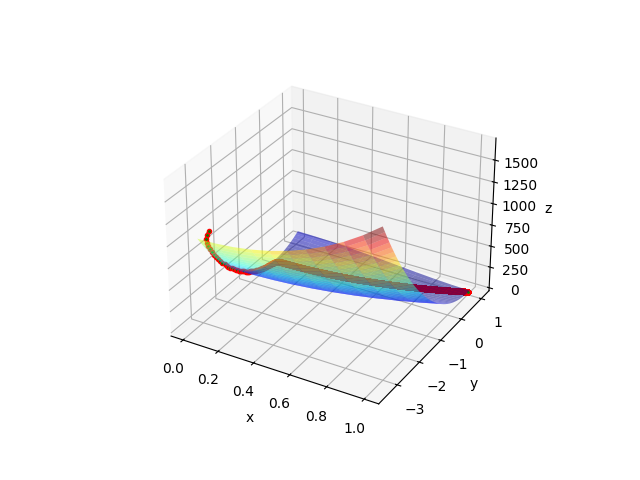

In [50]:
# Make data.
X = np.arange(history[:,0].min()*0.9, history[:,0].max()*1.1, 0.1)
Y = np.arange(history[:,1].min()*0.9, history[:,1].max()*1.1, 0.1)
XX, YY = np.meshgrid(X, Y)

Z = (a-XX)**2 + b*((YY-XX**2)**2)

# Plot the surface.
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(XX,YY,Z, cmap='jet', antialiased=True, alpha=0.5)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.plot(history[:,0], history[:,1], history[:,2], color='green', marker='.', markeredgecolor='red')

plt.show()

## Using a GPU in PyTorch

In [ ]:
#GPUs operations
#First check devices available (gpus or cpu), 'cuda' stands for gpus
if torch.cuda.is_available(): device = torch.device('cuda')
else: device = torch.device('cpu')

print(device)

In [ ]:
#Use function 'to' to move the tensors (those involved on the operation) to the current device
#When training your network don't forget to send the model (model.to(device)) 
#and the inputs (inputs.to(device)) to the correct device

tensor1 = torch.ones([2, 2]).to(device)
tensor2 = torch.ones([2, 2]).to(device)

operation = tensor1 + tensor2
print(operation)

In [ ]:
#Alternatively you can create the tensors directly on the device
tensorondevice = torch.ones([3, 3], device=device)